In [214]:
# Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [215]:
# Carga desde un archivo .csv sin indice
lr = pd.read_csv('Leads_reales.csv', header=[2]) 

In [216]:
# Verificamos información del DataFrame
lr.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   3 non-null      float64
 1   Mes                   33 non-null     str    
 2   Total                 31 non-null     str    
 3   Ilocalizable          32 non-null     str    
 4   No Contesta           31 non-null     str    
 5   D. Incorrectos        31 non-null     str    
 6   Duplicados            33 non-null     str    
 7   Efectivos             30 non-null     str    
 8   Abiertos              32 non-null     str    
 9   Ventas                30 non-null     str    
 10  Conversion            34 non-null     str    
 11  Efectividad de Leads  30 non-null     str    
 12  Unnamed: 12           2 non-null      float64
 13  Unnamed: 13           0 non-null      float64
dtypes: float64(3), str(11)
memory usage: 4.9 KB


In [217]:
# Limpiamos la base
lr.columns = lr.columns.str.strip()
lr["Año"] = lr["Año"].ffill()
lr["Año"] = lr["Año"].astype(int)
lr = lr[:28]
lr = lr.drop(index=0)
lr = lr.drop(columns=["Unnamed: 12", "Unnamed: 13"])

In [218]:
# Cambiamos tipos de datos
cols = ["Total","Ilocalizable","No Contesta","D. Incorrectos","Duplicados","Efectivos","Abiertos","Ventas"]
lr[cols] = lr[cols].replace(",", "", regex=True).astype(int)

lr["Conversion"] = lr["Conversion"].str.rstrip("%").astype(float)
lr["Efectividad de Leads"] = lr["Efectividad de Leads"].str.rstrip("%").astype(float)

In [219]:
# Verificamos nuevamente la información del DataFrame
lr.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 1 to 27
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   27 non-null     int64  
 1   Mes                   27 non-null     str    
 2   Total                 27 non-null     int64  
 3   Ilocalizable          27 non-null     int64  
 4   No Contesta           27 non-null     int64  
 5   D. Incorrectos        27 non-null     int64  
 6   Duplicados            27 non-null     int64  
 7   Efectivos             27 non-null     int64  
 8   Abiertos              27 non-null     int64  
 9   Ventas                27 non-null     int64  
 10  Conversion            27 non-null     float64
 11  Efectividad de Leads  27 non-null     float64
dtypes: float64(2), int64(9), str(1)
memory usage: 2.7 KB


In [220]:
# Calculamos el numero total de la población "n"
lr['Efectivos'].info()
n=27

<class 'pandas.Series'>
RangeIndex: 27 entries, 1 to 27
Series name: Efectivos
Non-Null Count  Dtype
--------------  -----
27 non-null     int64
dtypes: int64(1)
memory usage: 348.0 bytes


In [221]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=lr['Efectivos'].max()
Min=lr['Efectivos'].min()
Limites= [Min, Max]
Limites

[np.int64(128), np.int64(1040)]

In [222]:
# Calculamos el rango R
R=Max-Min
R

np.int64(912)

In [223]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.752127697007838)

In [224]:
# Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(158.5500267100133)

In [225]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(128, 1040, 6).astype(int)
intervalos

array([ 128,  310,  492,  675,  857, 1040])

In [226]:
#Creamos las categorías 
categorias = ["Muy bajo (128-310)", "Bajo (310-492)", "Medio (492-675)",
              "Alto (675-857)", "Muy alto (857-1040)"]

In [227]:
# Finalmente creamos las categorías en la columna numérica
lr['Efectivos']=pd.cut(x= lr['Efectivos'], bins=intervalos, labels= categorias)
lr['Efectivos']

1          Bajo (310-492)
2                     NaN
3      Muy bajo (128-310)
4      Muy bajo (128-310)
5         Medio (492-675)
6         Medio (492-675)
7         Medio (492-675)
8         Medio (492-675)
9          Alto (675-857)
10    Muy alto (857-1040)
11    Muy alto (857-1040)
12         Alto (675-857)
13         Bajo (310-492)
14         Alto (675-857)
15    Muy alto (857-1040)
16        Medio (492-675)
17         Alto (675-857)
18    Muy alto (857-1040)
19         Alto (675-857)
20        Medio (492-675)
21         Alto (675-857)
22         Alto (675-857)
23         Alto (675-857)
24         Alto (675-857)
25         Alto (675-857)
26    Muy alto (857-1040)
27         Alto (675-857)
Name: Efectivos, dtype: category
Categories (5, str): ['Muy bajo (128-310)' < 'Bajo (310-492)' < 'Medio (492-675)' < 'Alto (675-857)' < 'Muy alto (857-1040)']

In [228]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq = lr['Efectivos'].value_counts().reset_index()
Tabla_freq

,Efectivos,count
0,Alto (675-857),11
1,Medio (492-675),6
2,Muy alto (857-1040),5
3,Muy bajo (128-310),2
4,Bajo (310-492),2


In [229]:
#Ajusto el indice de mi dataframe
Tabla_freq_i = Tabla_freq.set_index('Efectivos')
Tabla_freq_i

,count
Efectivos,
Alto (675-857),11
Medio (492-675),6
Muy alto (857-1040),5
Muy bajo (128-310),2
Bajo (310-492),2


Text(0, 0.5, 'Frecuencia')

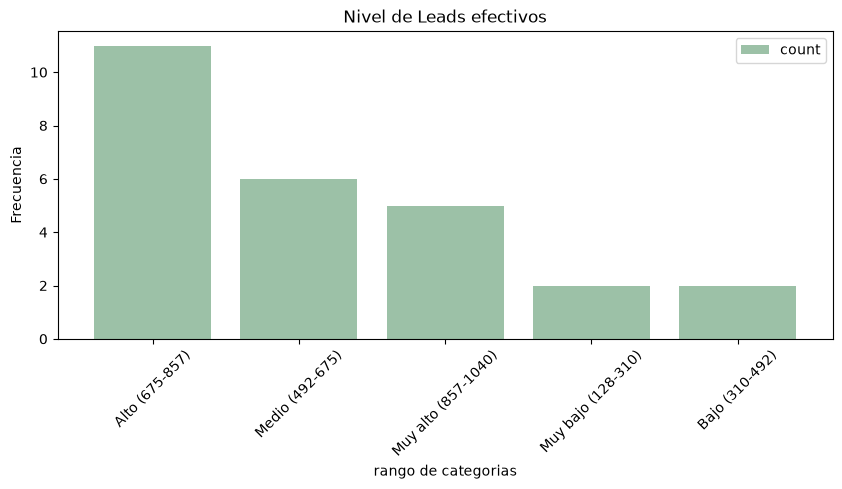

In [230]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "#9CC1A7", rot=45)
plt.title('Nivel de Leads efectivos')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

In [231]:
# Calculamos el numero total de la población "n"
lr['Abiertos'].info()
n=27

<class 'pandas.Series'>
RangeIndex: 27 entries, 1 to 27
Series name: Abiertos
Non-Null Count  Dtype
--------------  -----
27 non-null     int64
dtypes: int64(1)
memory usage: 348.0 bytes


In [232]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max1=lr['Abiertos'].max()
Min1=lr['Abiertos'].min()
Limites1= [Min1, Max1]
Limites1

[np.int64(1), np.int64(823)]

In [233]:
# Calculamos el rango R
R1=Max1-Min1
R1

np.int64(822)

In [234]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni1= 1+3.32*np.log10(n)
ni1

np.float64(5.752127697007838)

In [235]:
# Calculamos el Ancho del Intervalo "i"
i1=R1/ni1
i1

np.float64(142.90364249520937)

In [236]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos1=np.linspace(1, 823, 6).astype(int)
intervalos1

array([  1, 165, 329, 494, 658, 823])

In [237]:
categorias_abiertos = ["Muy bajo (1-165)", "Bajo (165-329)", "Medio (329-494)", "Alto (494-658)", "Muy alto (658-823)"]

In [238]:
# Finalmente creamos las categorías en la columna numérica
lr['Abiertos']=pd.cut(x= lr['Abiertos'], bins=intervalos1, labels= categorias_abiertos)
lr['Abiertos']

1                    NaN
2                    NaN
3                    NaN
4       Muy bajo (1-165)
5       Muy bajo (1-165)
6       Muy bajo (1-165)
7       Muy bajo (1-165)
8       Muy bajo (1-165)
9       Muy bajo (1-165)
10      Muy bajo (1-165)
11       Medio (329-494)
12        Bajo (165-329)
13      Muy bajo (1-165)
14      Muy bajo (1-165)
15      Muy bajo (1-165)
16        Bajo (165-329)
17        Bajo (165-329)
18        Bajo (165-329)
19       Medio (329-494)
20        Bajo (165-329)
21        Bajo (165-329)
22       Medio (329-494)
23    Muy alto (658-823)
24        Alto (494-658)
25        Alto (494-658)
26    Muy alto (658-823)
27        Alto (494-658)
Name: Abiertos, dtype: category
Categories (5, str): ['Muy bajo (1-165)' < 'Bajo (165-329)' < 'Medio (329-494)' < 'Alto (494-658)' < 'Muy alto (658-823)']

In [239]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq1 = lr['Abiertos'].value_counts().reset_index()
Tabla_freq1

,Abiertos,count
0,Muy bajo (1-165),10
1,Bajo (165-329),6
2,Medio (329-494),3
3,Alto (494-658),3
4,Muy alto (658-823),2


In [240]:
#Ajusto el indice de mi dataframe
Tabla_freq_i1 = Tabla_freq1.set_index('Abiertos')
Tabla_freq_i1

,count
Abiertos,
Muy bajo (1-165),10
Bajo (165-329),6
Medio (329-494),3
Alto (494-658),3
Muy alto (658-823),2


Text(0, 0.5, 'Frecuencia')

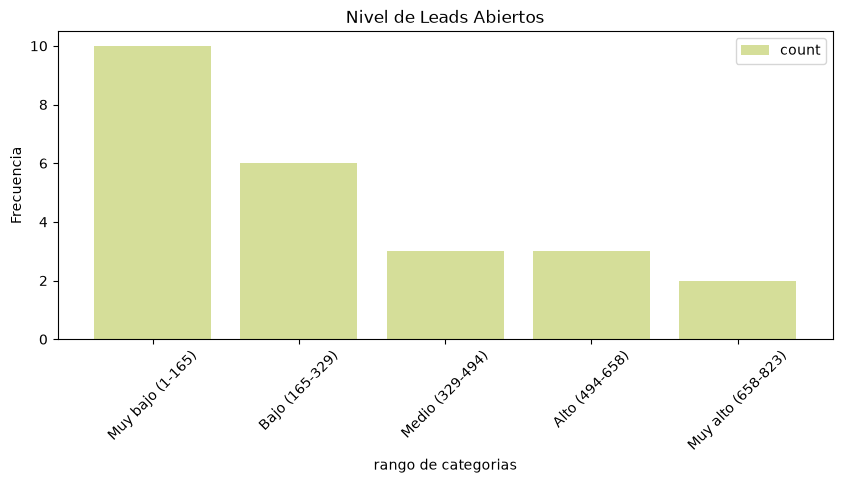

In [241]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i1.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "#D5DE99", rot=45)
plt.title('Nivel de Leads Abiertos')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

In [242]:
# Calculamos el numero total de la población "n"
lr['Ventas'].info()
n=27

<class 'pandas.Series'>
RangeIndex: 27 entries, 1 to 27
Series name: Ventas
Non-Null Count  Dtype
--------------  -----
27 non-null     int64
dtypes: int64(1)
memory usage: 348.0 bytes


In [243]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max2=lr['Ventas'].max()
Min2=lr['Ventas'].min()
Limites2= [Min2, Max2]
Limites2

[np.int64(6), np.int64(41)]

In [244]:
# Calculamos el rango R
R2=Max2-Min2
R2

np.int64(35)

In [245]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni2= 1+3.32*np.log10(n)
ni2

np.float64(5.752127697007838)

In [246]:
# Calculamos el Ancho del Intervalo "i"
i2=R2/ni2
i2

np.float64(6.084704972423756)

In [247]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos2=np.linspace(6, 41, 6).astype(int)
intervalos2

array([ 6, 13, 20, 27, 34, 41])

In [248]:
categorias_ventas = ["Muy bajo (6-13)", "Bajo (13-20)", "Medio (20-27)", "Alto (27-34)", "Muy alto (34-41)"]

In [249]:
# Finalmente creamos las categorías en la columna numérica
lr['Ventas']=pd.cut(x= lr['Ventas'], bins=intervalos2, labels= categorias_ventas)
lr['Ventas']

1      Muy bajo (6-13)
2      Muy bajo (6-13)
3      Muy bajo (6-13)
4      Muy bajo (6-13)
5                  NaN
6        Medio (20-27)
7         Bajo (13-20)
8         Bajo (13-20)
9        Medio (20-27)
10       Medio (20-27)
11        Alto (27-34)
12       Medio (20-27)
13        Bajo (13-20)
14        Alto (27-34)
15        Alto (27-34)
16        Alto (27-34)
17    Muy alto (34-41)
18    Muy alto (34-41)
19       Medio (20-27)
20    Muy alto (34-41)
21    Muy alto (34-41)
22    Muy alto (34-41)
23        Alto (27-34)
24    Muy alto (34-41)
25        Alto (27-34)
26    Muy alto (34-41)
27    Muy alto (34-41)
Name: Ventas, dtype: category
Categories (5, str): ['Muy bajo (6-13)' < 'Bajo (13-20)' < 'Medio (20-27)' < 'Alto (27-34)' < 'Muy alto (34-41)']

In [250]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq2 = lr['Ventas'].value_counts().reset_index()
Tabla_freq2

,Ventas,count
0,Muy alto (34-41),8
1,Alto (27-34),6
2,Medio (20-27),5
3,Muy bajo (6-13),4
4,Bajo (13-20),3


In [251]:
#Ajusto el indice de mi dataframe
Tabla_freq_i2 = Tabla_freq2.set_index('Ventas')
Tabla_freq_i2

,count
Ventas,
Muy alto (34-41),8
Alto (27-34),6
Medio (20-27),5
Muy bajo (6-13),4
Bajo (13-20),3


Text(0, 0.5, 'Frecuencia')

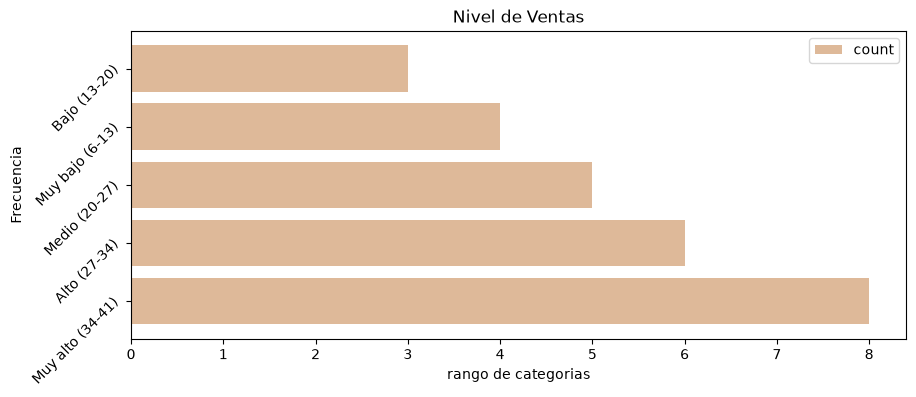

In [252]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i2.plot(kind = 'barh', width=0.8, figsize=(10,4), color= "#DEB999", rot=45)
plt.title('Nivel de Ventas')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')